# 実行例6.4 アヤメデータの非線形基底関数による変換とロジスティック回帰による識別（p.94図6.11~12,p.95図6.13）

- パッケージのインポート、関数類、データプロットなどは`6.3_iris-Fisher's_linear_discriminant.ipynb`を流用

In [1]:
using Pkg
Pkg.activate(@__DIR__)
using Statistics
using LinearAlgebra
using DataFrames
using CairoMakie

  Activating project at `c:\Users\salt_\OneDrive\Documents\!勉強\Julia\Pattern_recognition`


### 1. 対象データの準備

#### 1.1 アヤメデータの読み込み

In [2]:
# (1)iris.csvのファイルパスを設定する
filepath = "iris.csv"

# (2)iris.csvを読み出す
lines = open(filepath, "r") do io
    Iterators.drop(eachline(io), 1) |> collect
end

# (3)学習データ数の確認
N = length(lines)

# (4)データ配列の準備
sepal_length = Float64[]
sepal_width = Float64[]
petal_length = Float64[]
petal_width = Float64[]
Species = String[]

# (5)読み出した行をカンマ区切りのデータ配列にする
for line in lines
    rownames, sepal_length_x, sepal_width_x, petal_length_x, petal_width_x, species_x = split(line, ",")
    push!(sepal_length, parse(Float64, sepal_length_x))
    push!(sepal_width, parse(Float64, sepal_width_x))
    push!(petal_length, parse(Float64, petal_length_x))
    push!(petal_width, parse(Float64, petal_width_x))
    push!(Species, strip(species_x))
end

# (6)行列 + ラベルベクトル
X = hcat(sepal_length, sepal_width, petal_length, petal_width)  # N×4行列,Matrix{Float64},(150, 4)
y = Species # N要素のVector{String}

@show(typeof(X), size(X))

typeof(X) = Matrix{Float64}
size(X) = (150, 4)


(150, 4)

#### 1.2 クラス分けしたデータ準備

In [3]:
# (1)データサイズ
nrow, ncol = size(X)

# (2)クラスごとのデータ配列準備
# 配列形式のデータセットの準備
XC = Vector{Vector{Vector{Float64}}}()
# sts(setosa)
data_sts = [X[i, : ] for i in 1:nrow if y[i] == "setosa"]
# vsc(versicolor)
data_vsc = [X[i, : ] for i in 1:nrow if y[i] == "versicolor"]
# vgn(virginica)
data_vgn = [X[i, : ] for i in 1:nrow if y[i] == "virginica"]
# 配列形式のデータセットに要素を追加
XC = [data_sts, data_vsc, data_vgn]   # XC[1] : data_sts, XC[2] : data_sc, XC[3] : data_vgn

3-element Vector{Vector{Vector{Float64}}}:
 [[5.1, 3.5, 1.4, 0.2], [4.9, 3.0, 1.4, 0.2], [4.7, 3.2, 1.3, 0.2], [4.6, 3.1, 1.5, 0.2], [5.0, 3.6, 1.4, 0.2], [5.4, 3.9, 1.7, 0.4], [4.6, 3.4, 1.4, 0.3], [5.0, 3.4, 1.5, 0.2], [4.4, 2.9, 1.4, 0.2], [4.9, 3.1, 1.5, 0.1]  …  [5.0, 3.5, 1.3, 0.3], [4.5, 2.3, 1.3, 0.3], [4.4, 3.2, 1.3, 0.2], [5.0, 3.5, 1.6, 0.6], [5.1, 3.8, 1.9, 0.4], [4.8, 3.0, 1.4, 0.3], [5.1, 3.8, 1.6, 0.2], [4.6, 3.2, 1.4, 0.2], [5.3, 3.7, 1.5, 0.2], [5.0, 3.3, 1.4, 0.2]]
 [[7.0, 3.2, 4.7, 1.4], [6.4, 3.2, 4.5, 1.5], [6.9, 3.1, 4.9, 1.5], [5.5, 2.3, 4.0, 1.3], [6.5, 2.8, 4.6, 1.5], [5.7, 2.8, 4.5, 1.3], [6.3, 3.3, 4.7, 1.6], [4.9, 2.4, 3.3, 1.0], [6.6, 2.9, 4.6, 1.3], [5.2, 2.7, 3.9, 1.4]  …  [5.5, 2.6, 4.4, 1.2], [6.1, 3.0, 4.6, 1.4], [5.8, 2.6, 4.0, 1.2], [5.0, 2.3, 3.3, 1.0], [5.6, 2.7, 4.2, 1.3], [5.7, 3.0, 4.2, 1.2], [5.7, 2.9, 4.2, 1.3], [6.2, 2.9, 4.3, 1.3], [5.1, 2.5, 3.0, 1.1], [5.7, 2.8, 4.1, 1.3]]
 [[6.3, 3.3, 6.0, 2.5], [5.8, 2.7, 5.1, 1.9], [7.1, 3.0, 5.9, 2.1],

### 2. フィッシャーの基準によるクラス判別

#### 2.1 フィッシャーの基準の計算関数

In [4]:
# (1)共通統計値の算出
function stats_data(XC)
    # クラス数
    K = length(XC)
    # 次元数
    d = length(XC[1][1])    # length(first(first(XC)))と書けなくもない。
    # 各クラスのデータ数
    NC = length.(XC)
    # データ総数
    N = sum(NC)
    # 事前確率
    PC = NC ./ N
    # 平均ベクトル
    mc = mean.(XC)
    m_bar = mean(mc)

    return K, d, NC, N, PC, mc, m_bar
end

# (2)クラス間分散
function between_class_var(XC)   
    K, d, NC, N, PC, mc, m_bar = stats_data(XC)
    
    # クラス間分散
    σ_B2 = sum(PC[i] * (mc[i] - m_bar) * (mc[i] - m_bar)' for i in 1:K)

    return σ_B2
end

# (3)クラス内分散
function within_class_var(XC)
    K, d, NC, N, PC, mc, m_bar = stats_data(XC)
    
    # クラスごとの共分散行列
    Σ = [cov(reduce(hcat, XC[i])') for i in 1:K]
    
    # クラス内分散
    σ_W2 = sum(PC[i] * Σ[i] for i in 1:K)

    return σ_W2
end

within_class_var (generic function with 1 method)

#### 2.2 具体的なクラス間分散、クラス内分散の計算

In [5]:
# (1)クラス間分散、クラス内分散の計算
S_B = between_class_var(XC)
S_W = within_class_var(XC)
@show(S_B, S_W)

S_B = [0.4214142222222217 -0.13301777777777807 1.1016559999999993 0.47519555555555526; -0.13301777777777807 0.07563288888888903 -0.38159733333333395 -0.15288444444444477; 1.1016559999999993 -0.38159733333333395 2.9140186666666654 1.2451599999999998; 0.47519555555555526 -0.15288444444444477 1.2451599999999998 0.5360888888888888]
S_W = [0.2650081632653061 0.09272108843537412 0.16751428571428573 0.03840136054421769; 0.09272108843537412 0.11538775510204081 0.05524353741496598 0.03271020408163265; 0.16751428571428573 0.05524353741496598 0.18518775510204089 0.04266530612244897; 0.03840136054421769 0.03271020408163265 0.04266530612244897 0.04188163265306122]


4×4 Matrix{Float64}:
 0.265008   0.0927211  0.167514   0.0384014
 0.0927211  0.115388   0.0552435  0.0327102
 0.167514   0.0552435  0.185188   0.0426653
 0.0384014  0.0327102  0.0426653  0.0418816

#### 2.3 フィッシャーの線形判別関数による2次元判別空間への写像分布

In [6]:
# (１)固有値を求める
# 手順通りに行う場合
# A = inv(S_W) * S_B
# result = eigen(A)
# S_W^{-1} S_B の固有値問題 = 一般化固有値問題として解く場合（こちらの方が安定）
result = eigen(S_B, S_W)

# (2)固有値の大きい順に並び替える
idx = sortperm(result.values, rev=true)

# (3)上位2つの固有ベクトルを取り出してWを作る
W = result.vectors[:, idx[1:2]] # スライスで取り出せる

4×2 Matrix{Float64}:
 -0.829378  -0.0241021
 -1.53447   -2.16452
  2.20121    0.931921
  2.81046   -2.83919

#### 2.4 中心化した写像分布のプロット
- y軸方向は本に合わせて符号を反転させる。
- カンマは「要素を並べる」、セミコロンは「中身を連結する」という違いがある。
```julia
[a, b]   # → Vector{Vector{Point2f}}  ネストした配列
[a; b]   # → Vector{Point2f}          フラットに結合
```
- `CairoMakie`は`Vector{Vector{Float64}}`は受け取れないため`Point2f`（2軸のデータへの変換）への変換が必要

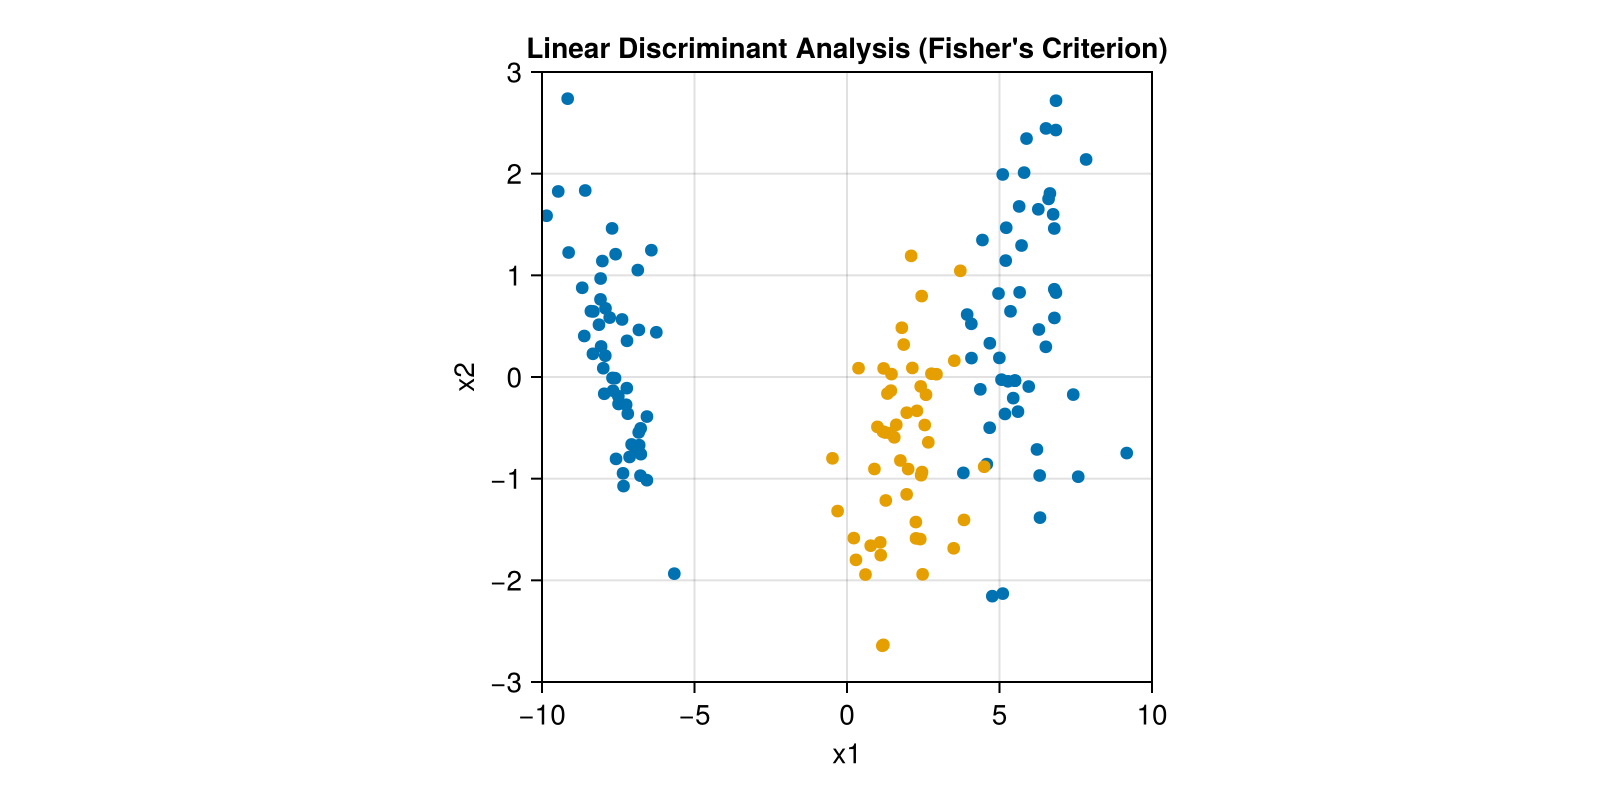

In [7]:
# (1)データの中心化
# 全体平均を引く
X_centered = X .- mean(X, dims=1)
# クラス分け
x_new_sts = [W' * X_centered[i, :] for i in 1:nrow if y[i] == "setosa"]
x_new_vsc = [W' * X_centered[i, :] for i in 1:nrow if y[i] == "versicolor"]
x_new_vgn = [W' * X_centered[i, :] for i in 1:nrow if y[i] == "virginica"]
# y軸の符号反転
x_sts = [[p[1], -p[2]] for p in [x_new_sts; x_new_vgn]]
x_vsc = [[p[1], -p[2]] for p in x_new_vsc]

# (2)プロット準備
fig =Figure(size=(800,400))
ax_a = Axis(fig[1, 1],
    title="Linear Discriminant Analysis (Fisher's Criterion)",
    xlabel="x1",
    ylabel="x2",
    xticks=-10.0:5.0:10.0,
    yticks=-3.0:1.0:3.0,
    limits=((-10.0, 10.0), (-3.0, 3.0)),
    aspect = AxisAspect(1)
)

# (3)データのプロット
scatter!(ax_a, Point2f.(x_sts))
scatter!(ax_a, Point2f.(x_vsc))

save("xoutput.png", fig)
fig

### 3. ロジスティック回帰による識別境界

#### 3.1 $\sigma(a) = 0.5$ の場合
- 識別境界を定める手順
    - 解析的には求められないので数値的に最小化を図る。
    - データ → w を求める → 境界を描く
        1. w を求める（式6.70）<br>
        交差エントロピー誤差関数 $\mathcal{L}(w)$ を数値的に最小化することでwを確定する。方法はニュートン－ラフソン法を使う。
        2. 識別境界を描く（式6.57の $a=0$ の条件）<br>
        事後確率が0.5になる点の集まりが境界になる。
        $$
        \text{式6.59 : } P(C_1|\boldsymbol{x}) = \frac{1}{1 + exp(-a)} = \sigma(a) \text{より} \\
        P(C_1|x) = \frac{1}{2} = 0.5 \iff \sigma(a) = 0.5 \iff a = 0 \iff \boldsymbol{w}^T \boldsymbol{x} = 0 \\
        (\boldsymbol{w} = (w_0, w_1)^T, \boldsymbol{x} = (1, x)^T, a = \boldsymbol{w}^T \boldsymbol{x})
        $$
    - 2次元なら $w_0 + w_1 x_1 + w_2 x_2 = 0$ という直線になる。これが図6.11の実線（確率0.5の等高線）で、0.2と0.8の等高線は破線で描かれている。
- 「識別境界を描くために$w$を使う」が正しく、「$w$を求めるために識別境界を使う」わけではない。$w$はあくまでデータと式6.70から求まる。
$$
\mathcal{L}(\pi_1, \cdots, \pi_N) = - \sum_{i=1}^{N} (t_i \ln \pi_i + (1 - t_i) \ln(1 - \pi_i))
$$
- コード例
    - 初期値 w → [π計算 → 勾配・ヘッセ計算 → w更新] を繰り返す → 収束したら終了
    - 各ステップのJuliaコード
    - 特徴量ベクトルxに対して
        - N : サンプル数（データ点の個数）
        - D : 特徴量の次元数
    ```julia
    # Step 1: シグモイド関数
    σ(a) = 1 / (1 + exp(-a))
  
    # Step 2: データ準備（バイアス項を追加）
    # X は N×D 行列, t は N次元の0/1ベクトル
    X_bias = hcat(ones(N), X)   # 先頭列に1を追加 → N×(D+1)

    # Step 3: ニュートン－ラフソン
    w = zeros(D + 1)   # 初期値

    for _ in 1:100
        π = σ.(X_bias * w)              # 各サンプルの事後確率 (N,)

        grad = X_bias' * (π - t)        # 勾配 (式6.71)

        R = Diagonal(π .* (1 .- π))    # 対角行列
        H = X_bias' * R * X_bias        # ヘッセ行列

        Δw = H \ grad                   # H^{-1} * grad
        w -= Δw

        norm(Δw) < 1e-6 && break        # 収束判定
    end
    ```
    - wが求まったあと、識別境界は $w^T x = 0$ なので、2次元なら：
    ```julia
    # x1 の範囲に対して境界上の x2 を計算
    x1_range = range(-10, 10, length=100)
    x2_boundary = [-(w[1] + w[2]*x1) / w[3] for x1 in x1_range]
    ```
    - 式と対応させると

    | コード | 対応する式 |
    |---|---|
    | `σ.(X_bias * w)` | $\pi_i = \sigma(\boldsymbol{w}^T \boldsymbol{x}_i)$ |
    | `X_bias' * (π - t)` | 式6.71 の勾配 |
    | `Diagonal(π .* (1 .- π))` | $R_{ii} = \pi_i(1-\pi_i)$ |
    | `X_bias' * R * X_bias` | $\boldsymbol{H} = \boldsymbol{X}^T \boldsymbol{R} \boldsymbol{X}$ |
    | `H \ grad` | $\boldsymbol{H}^{-1} \nabla \mathcal{L}$（`\` は線形方程式を解く演算子） |

    - `Diagonal(π .* (1 .- π))` : ベルヌーイ分布の分散を対角成分に持つ行列を作成している。
    - `H \ grad` : `\`は左除算演算子。連立一次方程式 $H \Delta w = \text{grad}$ を解いて $\Delta w$ を求める。$\Delta w = H^{-1} \text{grad}$ と同じ意味だが、`inv(H) * grad`より数値的に安定・高速


##### 【補足】
- ニュートン－ラフソン法
    - 方程式 $f(x) = 0$ を数値的に解く方法
    - イメージ：曲線 $f(x)$ の接線を引いて、その接線が $x$ 軸と交わる点を次の候補にする、を繰り返す。
    - 更新式 : 
    $$
    x_{\text{new}} = x_{\text{old}} - \frac{f(x_{\text{old}})}{f'(x_{\text{old}})}
    $$
    - ロジスティック回帰では「式6.71（勾配）= 0」という方程式を解きたい :
    $$
    w_{new} = w_{old} - H^{-1} \frac{\partial \mathcal{L}}{\partial w} \quad H : \text{ヘッセ行列（2階微分）}
    $$
- ヘッセ行列
    - 多変数関数における「2階微分を行列にまとめたもの」
    - 1変数の場合のおさらい
        - 関数 $f(x)$ の最小値を探すとき :
            - 1階微分 $f'(x)$：傾き（どっち方向に下るか）
            - 2階微分 $f''(x)$：曲率（どれくらい急カーブか）
        - ニュートン法の更新式 $x_\text{new} = x_\text{old} - \dfrac{f'}{f''}$ はこの2つを使っている。
    - 多変数になると $w = (w_0, w_1, w_2, \ldots)$ の場合、2階微分は「どの変数とどの変数の組み合わせか」で複数あるので、行列になる。
    - ヘッセ行列（Hessian matrix）
    $$
    H = \begin{pmatrix}
    \frac{\partial^2 \mathcal{L}}{\partial w_0^2} & \frac{\partial^2 \mathcal{L}}{\partial w_0 \partial w_1} & \cdots \\
    \frac{\partial^2 \mathcal{L}}{\partial w_1 \partial w_0} & \frac{\partial^2 \mathcal{L}}{\partial w_1^2} & \cdots \\
    \vdots & & \ddots
    \end{pmatrix}
    $$
    - ニュートン法の多変数版では $f''$ の代わりに $H^{-1}$（ヘッセ行列の逆行列）を使う。
    $$
    w_{new} = w_{old} - H^{-1} \frac{\partial \mathcal{L}}{\partial w}
    $$
    - 直感的には「曲率の情報を使って、最小値に向かって賢く進む」ための行列
- ベルヌーイ分布
    - 結果が「成功（1）」か「失敗（0）」の2通りしかない試行（ベルヌーイ試行）において、成功する確率を $p$ としたときの確率分布

In [8]:
# (1)ロジスティック回帰による識別関数
function logi_rgrss(x_1, x_2)
    # 変数の変換
    X = [x_1; x_2]
    # X は Vector{Point2f} → N×D の行列に変換
    X_mat = reduce(hcat, X)' 
    t = [ones(length(x_1)); zeros(length(x_2))]   # x_1→1, x_2→0

    # パラメーターの準備
    N = length(X)
    D = length(X[1])

    # シグモイド関数
    σ(a) = 1 / (1 + exp(-a))

    # データ準備（バイアス項を追加）
    # X は N×D 行列, t は N次元の0/1ベクトル
    X_bias = hcat(ones(N), X_mat)   # 先頭列に1を追加 → N×(D+1)

    # ニュートン－ラフソン
    w = zeros(D + 1)   # 初期値

    for _ in 1:100
        π = σ.(X_bias * w)              # 各サンプルの事後確率 (N,)

        grad = X_bias' * (π - t)        # 勾配 (式6.71)

        R = Diagonal(π .* (1 .- π))     # 対角行列
        H = X_bias' * R * X_bias        # ヘッセ行列

        Δw = H \ grad                   # H^{-1} * grad
        w -= Δw

        norm(Δw) < 1e-6 && break        # 収束判定
    end

    return w
end

# wの計算
w_05 = logi_rgrss(x_sts, x_vsc)

3-element Vector{Float64}:
  0.9943082118268267
 -0.12129750474313285
  1.1791725549968683

#### 3.2 $\sigma(a)\ne 0.5$ の場合
- σ(a) = p となる a は：
$$
a = \ln\frac{p}{1-p}
$$
なので：

```julia
w_02 = w .* log(0.2 / 0.8)   # σ(a) = 0.2 の等高線
w_08 = w .* log(0.8 / 0.2)   # σ(a) = 0.8 の等高線
```
- 本来は $w$ の向きはそのままでバイアス項だけずらすのが正確
```julia
a_02 = log(0.2 / 0.8)   # ≈ -1.386
a_08 = log(0.8 / 0.2)   # ≈  1.386
# バイアス項だけシフト
w_02 = [w[1] + a_02, w[2], w[3]]
w_08 = [w[1] + a_08, w[2], w[3]]
```
- aをs分ずらすと
$$
\sigma(a + s) = p \iff a = \ln\frac{p}{1-p} - s
$$
なので σ(a + shift) でずらすと境界は：
```julia
w0 + w1*x1 + w2*x2 + shift = 0
# → x2 = -(w0 + shift + w1*x1) / w2
```
となりバイアス項をずらすのと数学的に同じになるが、上記のバイアス項だけずらすのが境界描画コードを使い回しやすい。

In [9]:
# (1)σ(a)が0.2および0.8の場合
# aの計算
a_02 = log(0.2 / 0.8)   # ≈ -1.386
a_08 = log(0.8 / 0.2)   # ≈  1.386
# バイアス項だけシフト
w_02 = [w_05[1] + a_02, w_05[2], w_05[3]]
w_08 = [w_05[1] + a_08, w_05[2], w_05[3]]

3-element Vector{Float64}:
  2.3806025729467173
 -0.12129750474313285
  1.1791725549968683

#### 3.3 ロジスティック回帰による識別境界の描画

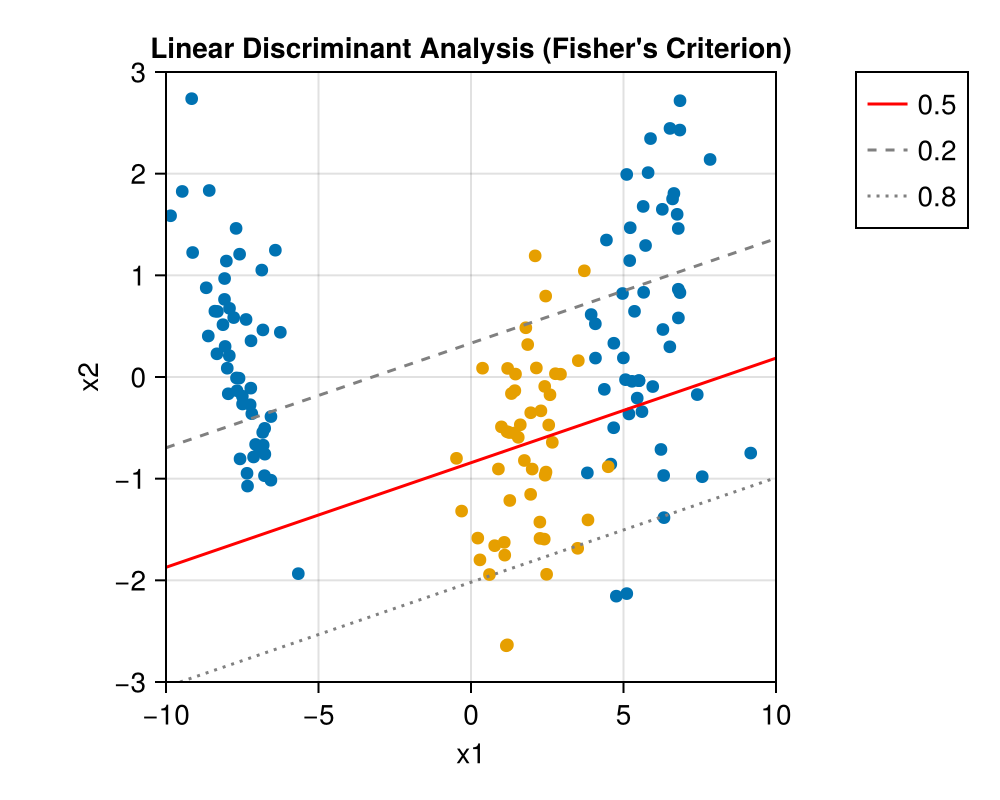

In [10]:
# (1)識別境界の計算関数
function boundary(w, x1_range)
    [[x1, -(w[1] + w[2]*x1) / w[3]] for x1 in x1_range]
end

# (2)識別境界の計算
x1_range = -10.0:0.1:10.0
pts_05 = boundary(w_05, x1_range)
pts_02 = boundary(w_02, x1_range)
pts_08 = boundary(w_08, x1_range)


# (3)プロット準備
fig =Figure(size=(500,400))
ax_a = Axis(fig[1, 1],
    title="Linear Discriminant Analysis (Fisher's Criterion)",
    xlabel="x1",
    ylabel="x2",
    xticks=-10.0:5.0:10.0,
    yticks=-3.0:1.0:3.0,
    limits=((-10.0, 10.0), (-3.0, 3.0)),
    aspect = AxisAspect(1)
)

# (4)データのプロット
scatter!(ax_a, Point2f.(x_sts))
scatter!(ax_a, Point2f.(x_vsc))

# (5)識別境界の描画
lines!(ax_a, Point2f.(pts_05), linestyle=:solid,color=:red, label="0.5")
lines!(ax_a, Point2f.(pts_02), linestyle=:dash, color=:gray, label="0.2")
lines!(ax_a, Point2f.(pts_08), linestyle=:dot, color=:gray, label="0.8")

# (6)凡例の表示
Legend(fig[1, 2], ax_a, valign=:top) 

save("xoutput.png", fig)
fig